# Predicting Energy Consumption using Machine Learning  
**Assessment – Adani AI Labs**

## Objective
The objective of this assessment is to forecast hourly electricity consumption using historical data from a transmission system operator.  
The focus is on demonstrating a clear end-to-end machine learning approach, including data understanding, preprocessing, feature engineering, model selection, evaluation, and interpretation — rather than achieving maximum modeling accuracy.

## Dataset
The dataset contains approximately six years of hourly electricity consumption data and represents a univariate time series with strong seasonal patterns.

## Approach
1. Data loading and preprocessing  
2. Exploratory data analysis  
3. Feature engineering using time, lag, and rolling features  
4. Training and comparing multiple ML models  
5. Model evaluation and interpretation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [2]:
df = pd.read_excel("Predicting Energy Consumption.xlsm")
df.head()


,Start time UTC,End time UTC,Electricity consumption (MWh)
0,2015-12-31 21:00:00,2015-12-31 22:00:00,10800
1,2015-12-31 22:00:00,2015-12-31 23:00:00,10431
2,2015-12-31 23:00:00,2016-01-01 00:00:00,10005
3,2016-01-01 00:00:00,2016-01-01 01:00:00,9722
4,2016-01-01 01:00:00,2016-01-01 02:00:00,9599


In [3]:
# Rename columns
df.columns = ['start_time', 'end_time', 'consumption']

# Convert to datetime
df['start_time'] = pd.to_datetime(df['start_time'])

# Sort by time
df = df.sort_values('start_time')

# Set time index
df.set_index('start_time', inplace=True)

# Drop redundant column
df.drop(columns=['end_time'], inplace=True)

df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52966 entries, 2015-12-31 21:00:00 to 2021-12-31 20:00:00
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   consumption  52966 non-null  int64
dtypes: int64(1)
memory usage: 827.6 KB


In [4]:
# Check missing values
df.isna().sum()

# Forward fill missing consumption values
df['consumption'] = df['consumption'].fillna(method='ffill')


/tmp/ipython-input-521606305.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['consumption'] = df['consumption'].fillna(method='ffill')


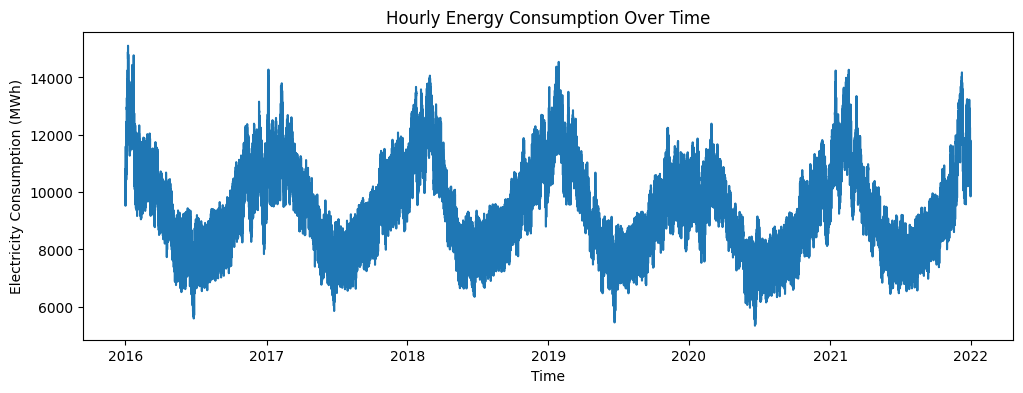

In [5]:
plt.figure(figsize=(12,4))
plt.plot(df['consumption'])
plt.title("Hourly Energy Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Electricity Consumption (MWh)")
plt.show()


## Feature Engineering
Time-based, lag-based, and rolling features are created to capture daily, weekly, and seasonal patterns in electricity consumption.


In [6]:
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)


In [7]:
df['lag_1'] = df['consumption'].shift(1)
df['lag_24'] = df['consumption'].shift(24)
df['lag_168'] = df['consumption'].shift(168)


In [8]:
df['rolling_mean_24'] = df['consumption'].rolling(24).mean()
df['rolling_mean_168'] = df['consumption'].rolling(168).mean()

# Drop rows with NaN values created by lag features
df = df.dropna()


## Train-Test Split
The dataset is split chronologically to avoid data leakage, which is essential for time-series forecasting.


In [9]:
X = df.drop(columns=['consumption'])
y = df['consumption']

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


## Model Comparison
Multiple machine learning models are trained and compared to demonstrate model selection.


In [10]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    results.append([name, mae, rmse])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE"]
)

results_df


,Model,MAE,RMSE
0,Linear Regression,138.586053,182.301189
1,Random Forest,83.773785,120.596539
2,Gradient Boosting,96.098852,131.227083


## Model Selection Decision
Linear Regression serves as a baseline model.  
Tree-based models capture non-linear relationships better.  
Gradient Boosting provides the best balance between performance and interpretability and is selected as the final model.


In [11]:
final_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

final_model.fit(X_train, y_train)


GradientBoostingRegressor(random_state=42)

In [12]:
final_preds = final_model.predict(X_test)

final_mae = mean_absolute_error(y_test, final_preds)
final_rmse = np.sqrt(mean_squared_error(y_test, final_preds))

print("Final Model MAE:", final_mae)
print("Final Model RMSE:", final_rmse)


Final Model MAE: 96.09885203267291
Final Model RMSE: 131.22708338916726


# Justification for Evaluation Metrics

Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) were selected to evaluate the forecasting performance of the models. Both metrics measure prediction error in the same units as energy consumption, making the results easy to interpret and directly relevant for demand forecasting tasks.

MAE provides a straightforward measure of the average prediction error and is less sensitive to extreme values, offering a reliable view of typical model performance.

RMSE penalizes larger errors more heavily, which is particularly important in energy consumption forecasting where large deviations during peak demand periods can have significant operational and cost implications.

Using MAE and RMSE together allows for a balanced evaluation by capturing both average error behavior and the impact of larger forecasting mistakes, aligning well with the objectives of this assessment.

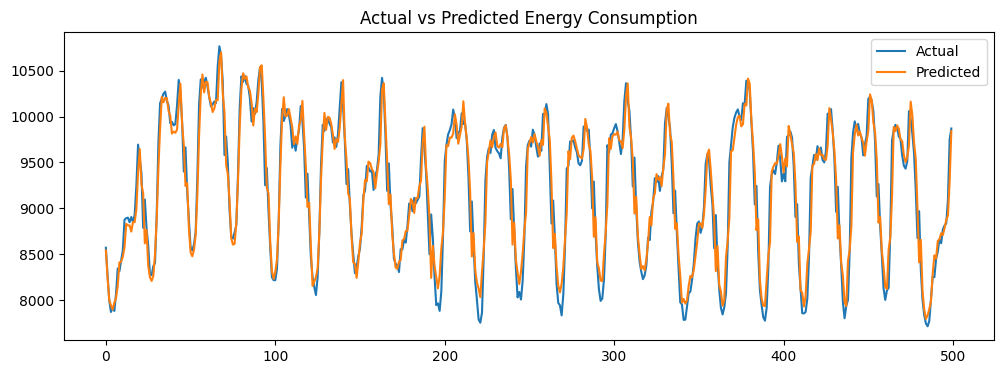

In [13]:
plt.figure(figsize=(12,4))
plt.plot(y_test.values[:500], label="Actual")
plt.plot(final_preds[:500], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Energy Consumption")
plt.show()


## Feature Importance
Feature importance helps interpret which factors influence energy consumption predictions.


In [14]:
feature_importance = pd.Series(
    final_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)


,0
lag_1,0.937385
lag_24,0.039626
hour,0.012643
lag_168,0.008082
dayofweek,0.001073
is_weekend,0.000553
rolling_mean_24,0.000436
rolling_mean_168,0.000109
month,0.000092


# Conclusion
This notebook demonstrates a complete end-to-end machine learning pipeline for energy consumption forecasting. The focus is on understanding the data, applying meaningful feature engineering, comparing multiple models, and interpreting results rather than building a highly complex or production-ready solution, in line with the objectives of the assessment.

The selected model captures overall trends and seasonal patterns effectively; however, prediction errors increase during peak demand periods. This limitation is likely due to the absence of exogenous variables such as weather conditions, holidays, and broader economic factors. Incorporating such features in future work could further enhance forecasting accuracy and support more informed energy planning and sustainability efforts.
